# WallMart Customers Life Time Value 

In [23]:
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from lifetimes import BetaGeoFitter, GammaGammaFitter, plotting
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from lifetimes.plotting import plot_frequency_recency_matrix, plot_probability_alive_matrix, plot_period_transactions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.pipeline import Pipeline
import pandas as pd
import lifetimes

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)


In [13]:
df = pd.read_csv('walmart.csv')
df

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,address,postcode,state,country,property_valuation
0,1,2,2950,2017-02-25 00:00:00,False,Approved,Solex,Standard,medium,medium,71.49,53.62,41245.0,984 Hoepker Court,3064,VIC,Australia,6
1,11065,1,2950,2017-10-16 00:00:00,False,Approved,Giant Bicycles,Standard,medium,medium,1403.50,954.82,37659.0,984 Hoepker Court,3064,VIC,Australia,6
2,18923,62,2950,2017-04-26 00:00:00,False,Approved,Solex,Standard,medium,medium,478.16,298.72,40487.0,984 Hoepker Court,3064,VIC,Australia,6
3,2,3,3120,2017-05-21 00:00:00,True,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701.0,4 Shopko Circle,2196,NSW,Australia,5
4,6862,4,3120,2017-10-05 00:00:00,False,Approved,Giant Bicycles,Standard,high,medium,1129.13,677.48,40649.0,4 Shopko Circle,2196,NSW,Australia,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19963,19854,68,130,2017-02-02 00:00:00,True,Approved,OHM Cycles,Standard,medium,medium,1636.90,44.71,40410.0,58 Helena Hill,2205,New South Wales,Australia,7
19964,17966,17,2789,2017-12-06 00:00:00,False,Approved,Solex,Standard,high,medium,1024.66,614.80,35378.0,724 West Park,2112,NSW,Australia,11
19965,18462,80,2789,2017-06-20 00:00:00,False,Approved,OHM Cycles,Touring,low,medium,1073.07,933.84,42226.0,724 West Park,2112,NSW,Australia,11
19966,17981,69,3446,2017-12-26 00:00:00,True,Approved,Giant Bicycles,Road,medium,medium,792.90,594.68,33879.0,8 Becker Drive,4868,QLD,Australia,4


# Data Visulization and EDA

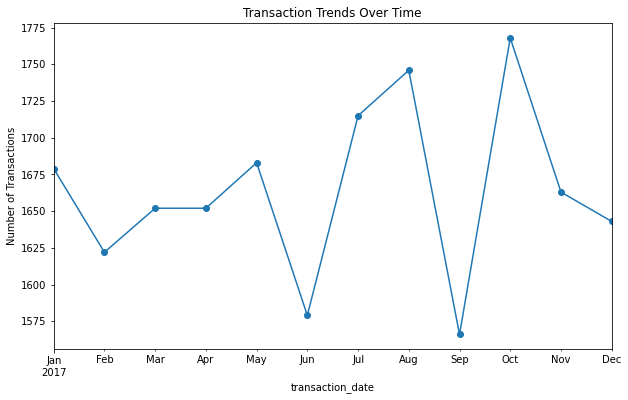

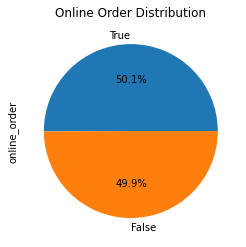

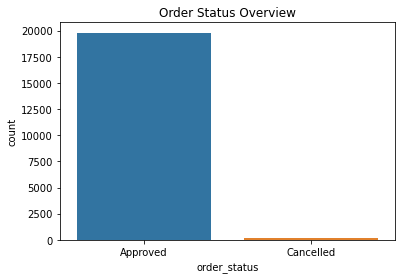

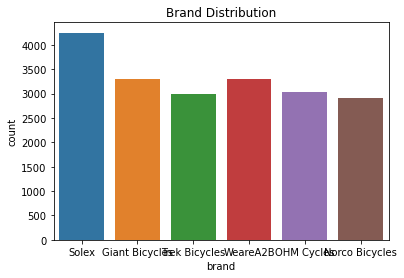

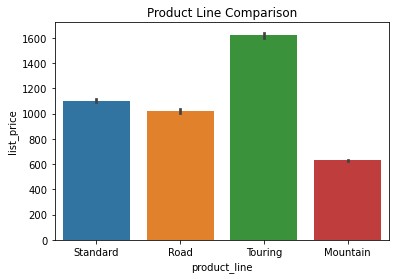

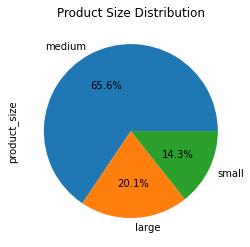

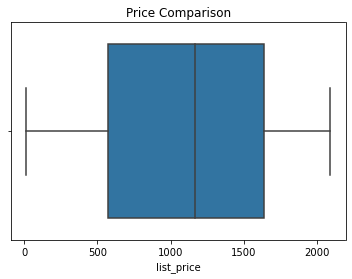

In [ ]:
# Data Visulization and EDA# Visualization 1: Transaction Trends Over Time
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df.set_index('transaction_date', inplace=True)
transaction_trends = df.resample('ME').size()
plt.figure(figsize=(10, 6))
transaction_trends.plot(style='-o', title='Transaction Trends Over Time', ylabel='Number of Transactions')
plt.show()

# Visualization 2: Online Order Distribution (Pie Chart)
online_order_distribution = df['online_order'].value_counts()
online_order_distribution.plot(kind='pie', autopct='%1.1f%%', title='Online Order Distribution')
plt.show()

# Visualization 3: Order Status Overview
sns.countplot(x='order_status', data=df)
plt.title('Order Status Overview')
plt.show()

# Visualization 4: Brand Distribution
sns.countplot(x='brand', data=df)
plt.title('Brand Distribution')
plt.show()

# Visualization 5: Product Line Comparison
sns.barplot(x='product_line', y='list_price', data=df)
plt.title('Product Line Comparison')
plt.show()

# Visualization 6: Product Size Distribution (Pie Chart)
product_size_distribution = df['product_size'].value_counts()
product_size_distribution.plot(kind='pie', autopct='%1.1f%%', title='Product Size Distribution')
plt.show()

# Visualization 8: Price Comparison
sns.boxplot(x='list_price', data=df)
plt.title('Price Comparison')
plt.show()

In [14]:
df.describe()

,transaction_id,product_id,customer_id,list_price,standard_cost,product_first_sold_date,postcode,property_valuation
count,19968.000000,19968.000000,19968.000000,19968.000000,19773.000000,19773.000000,19968.000000,19968.000000
mean,9997.846504,45.365986,1740.254307,1107.780004,556.091050,38198.741364,2987.623347,7.516376
std,5773.929973,30.750115,1009.819066,582.852548,405.966472,2874.856871,851.306647,2.824783
min,1.000000,0.000000,1.000000,12.010000,7.210000,33259.000000,2000.000000,1.000000
25%,4997.750000,18.000000,861.750000,575.270000,215.140000,35667.000000,2200.000000,6.000000
50%,9996.500000,44.000000,1739.500000,1163.890000,507.580000,38216.000000,2767.000000,8.000000
75%,14996.250000,72.000000,2614.250000,1635.300000,795.100000,40672.000000,3754.000000,10.000000
max,20000.000000,100.000000,3500.000000,2091.470000,1759.850000,42710.000000,4883.000000,12.000000


# Data Processing Feature Extraction and Clipping Outliers

In [82]:
df = df[df['list_price'] > 0 ]
df

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,address,postcode,state,country,property_valuation
0,1,2,2950,2017-02-25 00:00:00,False,Approved,Solex,Standard,medium,medium,71.49,53.62,41245.0,984 Hoepker Court,3064,VIC,Australia,6
1,11065,1,2950,2017-10-16 00:00:00,False,Approved,Giant Bicycles,Standard,medium,medium,1403.50,954.82,37659.0,984 Hoepker Court,3064,VIC,Australia,6
2,18923,62,2950,2017-04-26 00:00:00,False,Approved,Solex,Standard,medium,medium,478.16,298.72,40487.0,984 Hoepker Court,3064,VIC,Australia,6
3,2,3,3120,2017-05-21 00:00:00,True,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701.0,4 Shopko Circle,2196,NSW,Australia,5
4,6862,4,3120,2017-10-05 00:00:00,False,Approved,Giant Bicycles,Standard,high,medium,1129.13,677.48,40649.0,4 Shopko Circle,2196,NSW,Australia,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19963,19854,68,130,2017-02-02 00:00:00,True,Approved,OHM Cycles,Standard,medium,medium,1636.90,44.71,40410.0,58 Helena Hill,2205,New South Wales,Australia,7
19964,17966,17,2789,2017-12-06 00:00:00,False,Approved,Solex,Standard,high,medium,1024.66,614.80,35378.0,724 West Park,2112,NSW,Australia,11
19965,18462,80,2789,2017-06-20 00:00:00,False,Approved,OHM Cycles,Touring,low,medium,1073.07,933.84,42226.0,724 West Park,2112,NSW,Australia,11
19966,17981,69,3446,2017-12-26 00:00:00,True,Approved,Giant Bicycles,Road,medium,medium,792.90,594.68,33879.0,8 Becker Drive,4868,QLD,Australia,4


In [83]:
df.dropna(inplace=True)

In [15]:
def find_boundaries(df, variable,q1=0.05,q2=0.95):
    # the boundaries are the quantiles
    lower_boundary = df[variable].quantile(q1)
    upper_boundary = df[variable].quantile(q2)
    return upper_boundary, lower_boundary

def capping_outliers(df,variable):
    upper_boundary,lower_boundary =  find_boundaries(df,variable)
    df[variable] = np.where(df[variable] > upper_boundary, upper_boundary,
                       np.where(df[variable] < lower_boundary, lower_boundary, df[variable]))

In [16]:
capping_outliers(df,'list_price')

In [17]:
df.describe()

,transaction_id,product_id,customer_id,list_price,standard_cost,product_first_sold_date,postcode,property_valuation
count,19968.000000,19968.000000,19968.000000,19968.000000,19773.000000,19773.000000,19968.000000,19968.000000
mean,9997.846504,45.365986,1740.254307,1106.290129,556.091050,38198.741364,2987.623347,7.516376
std,5773.929973,30.750115,1009.819066,574.005710,405.966472,2874.856871,851.306647,2.824783
min,1.000000,0.000000,1.000000,100.350000,7.210000,33259.000000,2000.000000,1.000000
25%,4997.750000,18.000000,861.750000,575.270000,215.140000,35667.000000,2200.000000,6.000000
50%,9996.500000,44.000000,1739.500000,1163.890000,507.580000,38216.000000,2767.000000,8.000000
75%,14996.250000,72.000000,2614.250000,1635.300000,795.100000,40672.000000,3754.000000,10.000000
max,20000.000000,100.000000,3500.000000,1992.930000,1759.850000,42710.000000,4883.000000,12.000000


In [18]:
df

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date,address,postcode,state,country,property_valuation
0,1,2,2950,2017-02-25 00:00:00,False,Approved,Solex,Standard,medium,medium,100.35,53.62,41245.0,984 Hoepker Court,3064,VIC,Australia,6
1,11065,1,2950,2017-10-16 00:00:00,False,Approved,Giant Bicycles,Standard,medium,medium,1403.50,954.82,37659.0,984 Hoepker Court,3064,VIC,Australia,6
2,18923,62,2950,2017-04-26 00:00:00,False,Approved,Solex,Standard,medium,medium,478.16,298.72,40487.0,984 Hoepker Court,3064,VIC,Australia,6
3,2,3,3120,2017-05-21 00:00:00,True,Approved,Trek Bicycles,Standard,medium,large,1992.93,388.92,41701.0,4 Shopko Circle,2196,NSW,Australia,5
4,6862,4,3120,2017-10-05 00:00:00,False,Approved,Giant Bicycles,Standard,high,medium,1129.13,677.48,40649.0,4 Shopko Circle,2196,NSW,Australia,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19963,19854,68,130,2017-02-02 00:00:00,True,Approved,OHM Cycles,Standard,medium,medium,1636.90,44.71,40410.0,58 Helena Hill,2205,New South Wales,Australia,7
19964,17966,17,2789,2017-12-06 00:00:00,False,Approved,Solex,Standard,high,medium,1024.66,614.80,35378.0,724 West Park,2112,NSW,Australia,11
19965,18462,80,2789,2017-06-20 00:00:00,False,Approved,OHM Cycles,Touring,low,medium,1073.07,933.84,42226.0,724 West Park,2112,NSW,Australia,11
19966,17981,69,3446,2017-12-26 00:00:00,True,Approved,Giant Bicycles,Road,medium,medium,792.90,594.68,33879.0,8 Becker Drive,4868,QLD,Australia,4


# RMF Scoring

In [19]:
clv = lifetimes.utils.summary_data_from_transaction_data(df,'customer_id','transaction_date','list_price')

In [20]:
clv = clv[clv['frequency']>1] # we want only customers shopped more than 2 times

In [21]:
clv

,frequency,recency,T,monetary_value
customer_id,,,,
1,10.0,352.0,359.0,875.2910
2,2.0,112.0,240.0,1372.7850
5,5.0,286.0,302.0,1042.9140
6,4.0,272.0,336.0,1040.5125
7,2.0,62.0,315.0,337.4950
...,...,...,...,...
3496,3.0,42.0,298.0,1383.5800
3497,2.0,68.0,120.0,1584.4000
3498,5.0,203.0,330.0,770.9800


# Expected Transactions Determination

In [25]:
# Expected Transactions Determinationbgf = BetaGeoFitter(penalizer_coef=0.001)
bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(clv['frequency'], clv['recency'], clv['T'])

<lifetimes.BetaGeoFitter: fitted with 3235 subjects, a: 0.00, alpha: 445.20, b: 0.00, r: 7.26>

In [26]:
# Assuming 'T' is the customer's age at the time of the last observation
t = clv['T'].max()
clv['expected_purchases_all_time'] = bgf.conditional_expected_number_of_purchases_up_to_time(t, clv['frequency'], clv['recency'], clv['T'])
top_customers = clv.sort_values(by='expected_purchases_all_time', ascending=False) 


In [27]:
clv

,frequency,recency,T,monetary_value,expected_purchases_all_time
customer_id,,,,,
1,10.0,352.0,359.0,875.2910,7.791171
2,2.0,112.0,240.0,1372.7850,4.906103
5,5.0,286.0,302.0,1042.9140,5.956452
6,4.0,272.0,336.0,1040.5125,5.232542
7,2.0,62.0,315.0,337.4950,4.422076
...,...,...,...,...,...
3496,3.0,42.0,298.0,1383.5800,5.011654
3497,2.0,68.0,120.0,1584.4000,5.947737
3498,5.0,203.0,330.0,770.9800,5.741307


# Expected Transaction Charts

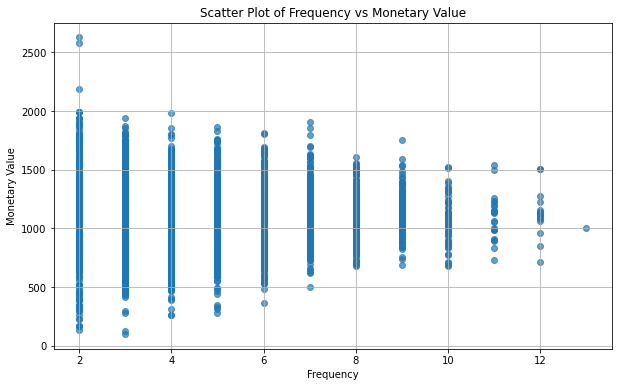

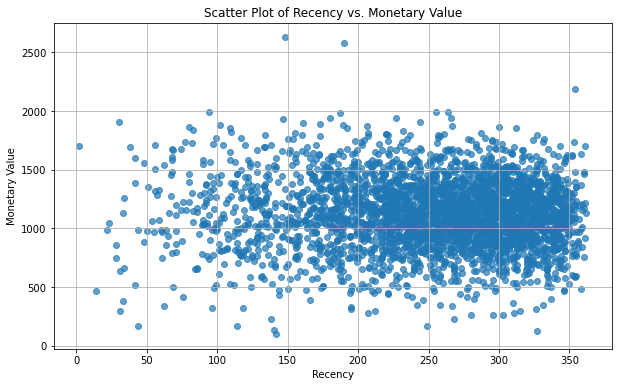

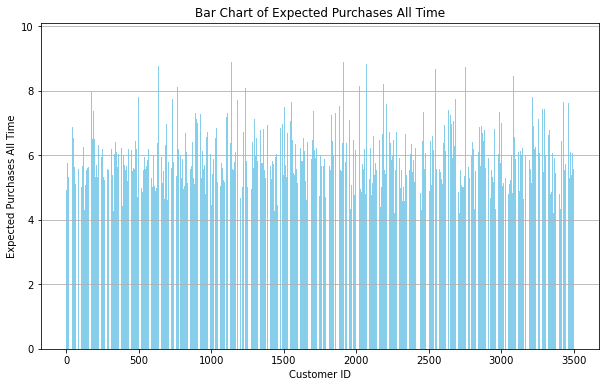

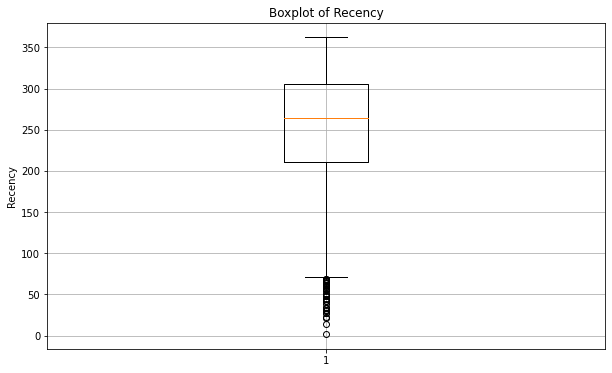

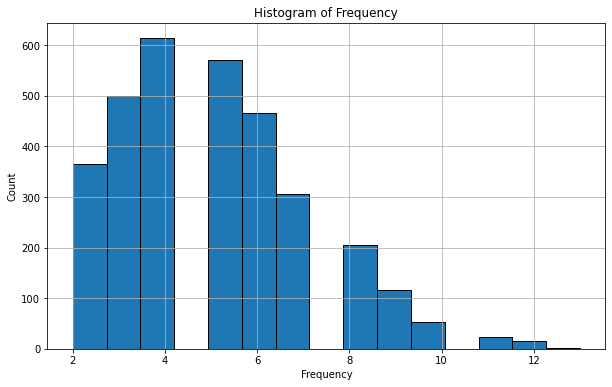

In [28]:
# Expected Value Determination# Visualize the 'frequency' and 'monetary_value' columns
plt.figure(figsize=(10, 6))
plt.scatter(clv['frequency'], clv['monetary_value'], alpha=0.7)
plt.title('Scatter Plot of Frequency vs Monetary Value')
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 6))
plt.scatter(clv['recency'], clv['monetary_value'], alpha=0.7)
plt.title('Scatter Plot of Recency vs. Monetary Value')
plt.xlabel('Recency')
plt.ylabel('Monetary Value')
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 6))
plt.bar(clv.index, clv['expected_purchases_all_time'], color='skyblue')
plt.title('Bar Chart of Expected Purchases All Time')
plt.xlabel('Customer ID')
plt.ylabel('Expected Purchases All Time')
plt.grid(axis='y')
plt.show()
plt.figure(figsize=(10, 6))
plt.boxplot(clv['recency'])
plt.title('Boxplot of Recency')
plt.ylabel('Recency')
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 6))
plt.hist(clv['frequency'], bins=15, edgecolor='black')
plt.title('Histogram of Frequency')
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.grid(True)
plt.show()


# Expected Value Determination

In [29]:
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(clv["frequency"],
        clv["monetary_value"])

<lifetimes.GammaGammaFitter: fitted with 3235 subjects, p: 3.36, q: 0.23, v: 3.31>

In [30]:
clv['All-time']=ggf.customer_lifetime_value(bgf,
                                   clv["frequency"],
                                   clv["recency"],
                                   clv["T"],
                                   clv["monetary_value"],
                                   time=t,
                                   freq='D',
                                   discount_rate=0.01)

In [31]:
 clv.sort_values('All-time',ascending=False).head()

,frequency,recency,T,monetary_value,expected_purchases_all_time,All-time
customer_id,,,,,,
1903,2.0,148.0,164.0,2625.970000,5.518157,131688.707990
1317,7.0,244.0,254.0,1909.104286,7.403690,117536.362483
2183,12.0,289.0,297.0,1508.401667,9.420182,116508.989928
1129,12.0,277.0,303.0,1504.887500,9.344639,115305.467906
3118,8.0,177.0,189.0,1530.287500,8.734878,110687.907695


# Expected Value Charts

Text(0.5, 1.0, 'Monetary Value vs All-time Purchases')

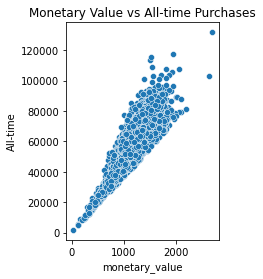

In [33]:
# Expected Value Determinationplt.subplot(1, 2, 2)
sns.scatterplot(x='monetary_value', y='All-time', data=clv)
plt.title('Monetary Value vs All-time Purchases')


# Customers Segmentation

In [33]:
clv['Segment'] =  pd.qcut(clv['All-time'],4,labels = ['Inactive','Requires Attension',
                                                          'Loyal Customers','Gold Members (Premiun)'])

In [34]:
clv

,frequency,recency,T,monetary_value,expected_purchases_all_time,All-time,Segment
customer_id,,,,,,,
1,10.0,352.0,359.0,875.2910,7.791171,56145.869797,Requires Attension
2,2.0,112.0,240.0,1372.7850,4.906103,61242.575347,Loyal Customers
5,5.0,286.0,302.0,1042.9140,5.956452,52386.515015,Requires Attension
6,4.0,272.0,336.0,1040.5125,5.232542,46479.445349,Requires Attension
7,2.0,62.0,315.0,337.4950,4.422076,13620.985156,Inactive
...,...,...,...,...,...,...,...
3496,3.0,42.0,298.0,1383.5800,5.011654,60419.525012,Loyal Customers
3497,2.0,68.0,120.0,1584.4000,5.947737,85676.368821,Gold Members (Premiun)
3498,5.0,203.0,330.0,770.9800,5.741307,37336.565405,Inactive


# Visusalization

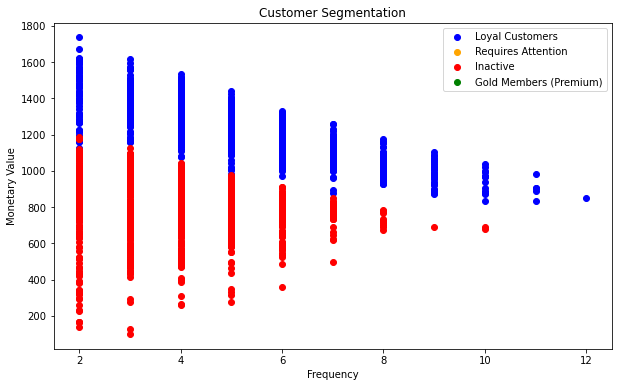

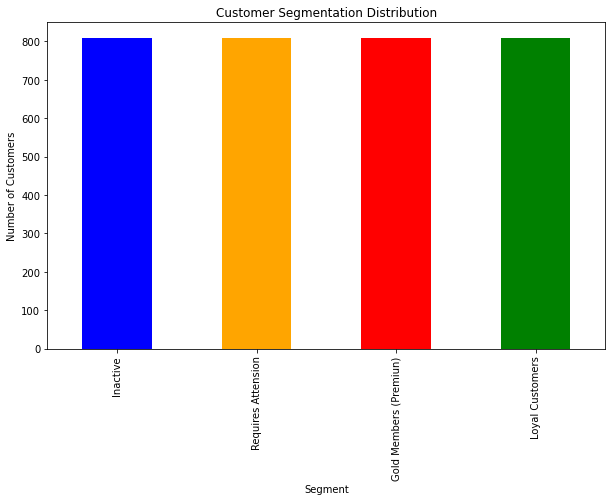

In [35]:
# Plot based on the cluster
colors = {
    'Loyal Customers': 'blue',
    'Requires Attention': 'orange',
    'Inactive': 'red',
    'Gold Members (Premium)': 'green'
}

plt.figure(figsize=(10, 6))

for segment, color in colors.items():
    segment_data = clv[clv['Segment'] == segment]
    plt.scatter(segment_data['frequency'], segment_data['monetary_value'], label=segment, color=color)

plt.title('Customer Segmentation')
plt.xlabel('Frequency')
plt.ylabel('Monetary Value')
plt.legend()
plt.show()

# Count the number of customers in each segment
segment_counts = clv['Segment'].value_counts()

# Plot a bar chart
plt.figure(figsize=(10, 6))
segment_counts.plot(kind='bar', color=['blue', 'orange', 'red', 'green'])
plt.title('Customer Segmentation Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()

# Regressor Training/Evalaution for Lifetime Value Prediction

In [36]:
# Expected Value Determination# Separate features and target variable for CLV prediction
clv_features = clv[['frequency', 'recency', 'T', 'monetary_value' ]]
clv_target = clv['All-time']

# Split the data into training and testing sets for CLV prediction
clv_X_train, clv_X_test, clv_y_train, clv_y_test = train_test_split(clv_features, clv_target, test_size=0.2, random_state=42)

# Train a Linear Regression model for CLV prediction
clv_model = LinearRegression()
clv_model.fit(clv_X_train, clv_y_train)

# Make predictions on the test set
clv_predictions = clv_model.predict(clv_X_test)

# Evaluate the CLV prediction model
mse = mean_squared_error(clv_y_test, clv_predictions)
print(f'Mean Squared Error for CLV Prediction: {mse}')

Mean Squared Error for CLV Prediction: 4492418.709240541


In [37]:
 # Standardize features for Random Forest Regressor
scaler = StandardScaler()
clv_X_train_scaled = scaler.fit_transform(clv_X_train)
clv_X_test_scaled = scaler.transform(clv_X_test)

# Train a Random Forest Regressor for CLV prediction
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(clv_X_train_scaled, clv_y_train)

# Make predictions on the test set
clv_predictions_rf = rf_model.predict(clv_X_test_scaled)

# Evaluate the Random Forest Regressor model
mse_rf = mean_squared_error(clv_y_test, clv_predictions_rf)
print(f'Mean Squared Error for CLV Prediction (Random Forest): {mse_rf}')

Mean Squared Error for CLV Prediction (Random Forest): 4867882.17304636


# Classifier Training/Evalaution for Customer Segmentation

In [38]:
# Separate features and target variable for Segment prediction
segment_features = clv[['frequency', 'recency', 'T', 'monetary_value', 'All-time']]
segment_target = clv['Segment']

# Split the data into training and testing sets for Segment prediction
segment_X_train, segment_X_test, segment_y_train, segment_y_test = train_test_split(segment_features, segment_target, test_size=0.2, random_state=42)

# Create a pipeline for preprocessing and training the Random Forest Classifier
segment_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train the Random Forest Classifier for Segment prediction
segment_pipeline.fit(segment_X_train, segment_y_train)

# Make predictions on the test set
segment_predictions = segment_pipeline.predict(segment_X_test)

# Evaluate the Segment prediction model
accuracy = accuracy_score(segment_y_test, segment_predictions)
print(f'Accuracy for Segment Prediction: {accuracy}')

# Display classification report for more detailed metrics
print(classification_report(segment_y_test, segment_predictions))

Accuracy for Segment Prediction: 1.0
                        precision    recall  f1-score   support

Gold Members (Premiun)       1.00      1.00      1.00       153
              Inactive       1.00      1.00      1.00       180
       Loyal Customers       1.00      1.00      1.00       159
    Requires Attension       1.00      1.00      1.00       155

              accuracy                           1.00       647
             macro avg       1.00      1.00      1.00       647
          weighted avg       1.00      1.00      1.00       647



# Saving Models

In [39]:
import joblib
# Save Random Forest Regressor model for CLV prediction
joblib.dump(rf_model, 'clv_rf_model.joblib')
# Save Segment prediction pipeline
joblib.dump(segment_pipeline, 'segment_pipeline.joblib')
# Load Random Forest Regressor model for CLV prediction
loaded_rf_model = joblib.load('clv_rf_model.joblib')
# Load Segment prediction pipeline
loaded_segment_pipeline = joblib.load('segment_pipeline.joblib')
# Saving Models

In [40]:
def predict_clv(new_customer_features):
    # Ensure that the new customer features are in the correct order
    new_customer_features = pd.DataFrame([new_customer_features], columns=['frequency', 'recency', 'T', 'monetary_value'])

    # Standardize the features for the Random Forest Regressor
    new_customer_features_scaled = scaler.transform(new_customer_features)

    # Predict CLV using the Random Forest Regressor
    clv_prediction = rf_model.predict(new_customer_features_scaled)[0]
    return clv_prediction

# Example usage:
new_customer_features = [58, 100, 150, 5000]  # Replace with the actual features of the new customer
predicted_clv = predict_clv(new_customer_features)

print(f'Predicted Segment: {predicted_clv}')


Predicted Segment: 109511.14671009286


# Prediction Fucntions

In [41]:
def predict_clv(new_customer_features):
    # Ensure that the new customer features are in the correct order
    new_customer_features = pd.DataFrame([new_customer_features], columns=['frequency', 'recency', 'T', 'monetary_value'])

    # Standardize the features for the Random Forest Regressor
    new_customer_features_scaled = scaler.transform(new_customer_features)

    # Predict CLV using the Random Forest Regressor
    clv_prediction = rf_model.predict(new_customer_features_scaled)[0]
    return clv_prediction

# Example usage:
new_customer_features = [58, 100, 150, 5000]  # Replace with the actual features of the new customer
predicted_clv = predict_clv(new_customer_features)

print(f'Predicted Segment: {predicted_clv}')

def predict_segment(new_customer_features):
    # Ensure that the new customer features are in the correct order
    new_customer_features = pd.DataFrame([new_customer_features], columns=['frequency', 'recency', 'T', 'monetary_value', 'All-time'])

    # Use the trained pipeline to standardize features and predict segment
    new_customer_segment = segment_pipeline.predict(new_customer_features)[0]
    return new_customer_segment

# Example usage:
new_customer_features = [58, 100, 150, 5000, 50000]  # Replace with the actual features of the new customer
predicted_segment = predict_segment(new_customer_features)

print(f'Predicted Segment: {predicted_segment}')


Predicted Segment: 109511.14671009286
Predicted Segment: Requires Attension


In [42]:

def predict_clv_and_segment(new_customer_features, clv_model_path='clv_rf_model.joblib', segment_model_path='segment_pipeline.joblib', scaler_path='standard_scaler.joblib'):
    # Load Random Forest Regressor model for CLV prediction
    loaded_rf_model = joblib.load(clv_model_path)

    # Load Segment prediction pipeline
    loaded_segment_pipeline = joblib.load(segment_model_path)

    # Load StandardScaler from file
    scaler = joblib.load(scaler_path)

    # Ensure that the new customer features are in the correct order for CLV prediction
    clv_features = pd.DataFrame([new_customer_features], columns=['frequency', 'recency', 'T', 'monetary_value'])

    # Standardize features for CLV prediction using the loaded scaler
    clv_features_scaled = scaler.transform(clv_features)

    # Predict CLV using the Random Forest Regressor
    clv_all_time_prediction = loaded_rf_model.predict(clv_features_scaled)[0]

    # Concatenate the 'All-time' prediction with the original features
    clv_features['All-time'] = clv_all_time_prediction

    # Ensure that the new customer features are in the correct order for Segment prediction
    segment_features = clv_features.copy()

    # Predict Segment using the trained pipeline
    segment_prediction = loaded_segment_pipeline.predict(segment_features)[0]

    return clv_all_time_prediction, segment_prediction

# Example usage:
new_customer_features_clv_segment = [58, 100, 150, 1500]  # Replace with the actual features of the new customer
predicted_clv, predicted_segment = predict_clv_and_segment(new_customer_features_clv_segment)

print(f'Predicted CLV (All-time): {predicted_clv}')
print(f'Predicted Segment: {predicted_segment}')


Predicted CLV (All-time): 103455.11442665596
Predicted Segment: Gold Members (Premiun)


In [43]:
import sklearn
print("scikit-learn version:", sklearn.__version__)


scikit-learn version: 1.0.2


End of Notebook